# Figure 3 · How many positions: the physics prior pays most for the higher modes

Production notebook for main-text Fig. 3. Soft probe learning curves from notebook 02a (dense map
at 1 µm, 346 positions, equispaced designs N = 3–30, `results/_cache_02a.json`); stiff probe
learning curves from `tools/run_2s.py` (`results/_cache_02s.json`, same protocol).

Arms, scored per CR band on held-out positions: **EB** (single-band physics), **EB+GP**, **GP**,
**low-rank**. Crossover N = the smallest N from which a data-only arm stays at or below EB+GP for
every larger N (notebook 02a definition).

In [1]:
%matplotlib inline
import sys, pathlib
# make the paper package importable when running from notebooks/
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import fmmpaper as F
from fmmpaper import io, axis, spectra, domains, recon, plotting as fp, results
fp.setup()
print(F.config.describe())

project : /home/claude/work/paper_analysis
data_root: /mnt/user-data/uploads/ActiveModeMap  (ok)
amm_repo : /home/claude/work  (ok)
eb_repo  : C:\Users\lz1\Documents\Github\EB-Solver-CResonance  (MISSING)
fmm_code_zip: /mnt/user-data/uploads/ActiveModeMap_repo/Manuscript_FMM/FMM_analysis_code.zip  (ok)


In [2]:
import json
P3 = pd.read_csv(F.config.RESULTS_DIR / "fig3_ppp_per_mode.csv")
V3 = json.loads((F.config.RESULTS_DIR / "fig3_ppp_per_mode.json").read_text())["values"]
CS = json.loads((F.config.RESULTS_DIR / "_cache_02s.json").read_text())
S3 = pd.DataFrame([dict(mode=k.split("|")[0], N=int(k.split("|")[1]), arm=a, nrmse=v[a]["nrmse"], node_err_um=v[a]["node_err_um"])
                   for k, v in CS.items() if "|" in k for a in ("EB", "EB+GP", "GP", "low-rank") if a in v])
BANDS = ["CR1", "CR2", "CR3", "CR4", "CR5"]

def crossover(d, data_arm, phys="EB+GP"):
    p = d[d.arm == phys].set_index("N").nrmse; q = d[d.arm == data_arm].set_index("N").nrmse
    ns = sorted(set(p.index) & set(q.index))
    for i, n in enumerate(ns):
        if all(q[m] <= p[m] for m in ns[i:]):
            return n
    return np.nan                       # never, up to the largest N tested

XO = pd.DataFrame([dict(probe=pr, mode=b, GP=crossover(D[D["mode"] == b], "GP"), lowrank=crossover(D[D["mode"] == b], "low-rank"),
                        floor=D[(D["mode"] == b) & (D.arm == "EB") & (D.N >= 10)].nrmse.median())
                   for pr, D, bands in (("soft", P3, BANDS), ("stiff", S3, BANDS[:3])) for b in bands])
XO

,probe,mode,GP,lowrank,floor
0,soft,CR1,4,5.0,0.149315
1,soft,CR2,8,6.0,0.181241
2,soft,CR3,6,NaN,0.332456
3,soft,CR4,8,NaN,0.465029
4,soft,CR5,8,NaN,0.552592
5,stiff,CR1,5,3.0,0.157395
6,stiff,CR2,30,NaN,0.140395
7,stiff,CR3,6,NaN,0.282373


## The figure

[PosixPath('/home/claude/work/paper_analysis/figures/Fig3_how_many_and_where.png'),
 PosixPath('/home/claude/work/paper_analysis/figures/Fig3_how_many_and_where.pdf')]

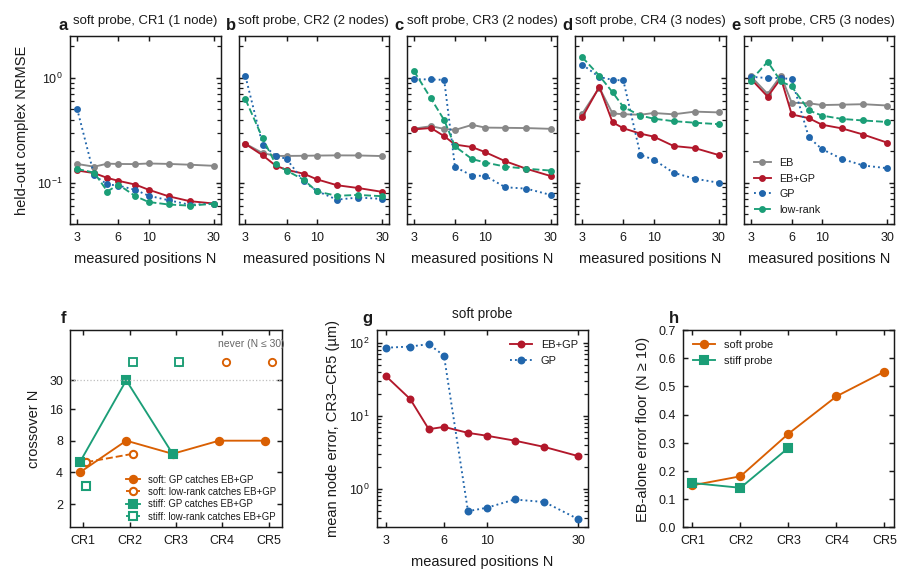

In [3]:
from matplotlib.gridspec import GridSpec
fig = plt.figure(figsize=(fp.WIDTH_IN["double"], fp.WIDTH_IN["double"] * 0.6))
gs = GridSpec(2, 1, figure=fig, height_ratios=[1, 1.05], hspace=0.55)
g1 = gs[0].subgridspec(1, 5, wspace=0.12); g2 = gs[1].subgridspec(1, 3, wspace=0.45)
STY = (("EB", fp.C["eb"], "-"), ("EB+GP", fp.C["ebgp"], "-"), ("GP", fp.C["gp"], ":"), ("low-rank", fp.C["lowrank"], "--"))
for j, b in enumerate(BANDS):
    ax = fig.add_subplot(g1[0, j])
    for arm, c, ls in STY:
        d = P3[(P3["mode"] == b) & (P3.arm == arm)].sort_values("N")
        ax.plot(d.N, d.nrmse, ls, color=c, marker="o", ms=2.3, lw=0.9, label=arm)
    fp.n_axis(ax, ticks=(3, 6, 10, 30)); ax.set_yscale("log"); ax.set_ylim(0.04, 2.5)
    nn = len(V3["truth_nodes"][b])
    ax.set_title(f"soft probe, {b} ({nn} node{'s' if nn != 1 else ''})", fontsize=6.3)
    ax.set_xlabel("measured positions N")
    if j == 0:
        ax.set_ylabel("held-out complex NRMSE")
    else:
        ax.set_yticklabels([])
    if j == 4:
        ax.legend(loc="lower left", fontsize=5.2, handlelength=1.6)
    fp.panel_label(ax, "abcde"[j])

# f  crossover N vs mode, both probes
axf = fig.add_subplot(g2[0, 0])
for pr, mk, c in (("soft", "o", "#d95f02"), ("stiff", "s", "#1b9e77")):
    d = XO[XO.probe == pr]; n = d["mode"].str[2].astype(int)
    axf.plot(n - 0.07, d.GP, mk + "-", color=c, ms=3.5, lw=0.9, label=f"{pr}: GP catches EB+GP")
    lr = d.lowrank.values
    axf.plot(n + 0.07, np.where(np.isnan(lr), np.nan, lr), mk + "--", color=c, mfc="w", ms=3.5, lw=0.9, label=f"{pr}: low-rank catches EB+GP")
    nev = np.isnan(lr)
    axf.plot((n + 0.07)[nev], np.full(nev.sum(), 45), mk, color=c, mfc="w", ms=3.5, mew=0.9)
axf.axhline(30, color="0.75", lw=0.6, ls=":"); axf.text(5.35, 62, "never (N ≤ 30)", fontsize=5, color="0.4", ha="right")
axf.set_yscale("log"); axf.set_ylim(1.2, 90); axf.set_xticks(range(1, 6)); axf.set_xticklabels(BANDS)
from matplotlib.ticker import FixedLocator, ScalarFormatter, NullLocator
axf.yaxis.set_major_locator(FixedLocator([2, 4, 8, 16, 30])); axf.yaxis.set_major_formatter(ScalarFormatter()); axf.yaxis.set_minor_locator(NullLocator())
axf.set_ylabel("crossover N"); axf.legend(loc="lower right", fontsize=4.6, handlelength=1.5, labelspacing=0.25, borderaxespad=0.2)
fp.panel_label(axf, "f")

# g  node recovery vs N, soft probe CR3-CR5, EB+GP vs GP
axg = fig.add_subplot(g2[0, 1])
for arm, c, ls in STY[1:3]:
    d = P3[(P3.arm == arm) & (P3["mode"].isin(["CR3", "CR4", "CR5"]))].copy()
    d["node_err_um"] = d.node_err_um.astype(float).clip(upper=100)
    m = d.groupby("N").node_err_um.mean()
    axg.plot(m.index, m.values, ls, color=c, marker="o", ms=2.8, lw=0.9, label=arm)
fp.n_axis(axg, ticks=(3, 6, 10, 30)); axg.set_yscale("log"); axg.set_ylim(0.3, 150)
axg.set_xlabel("measured positions N"); axg.set_ylabel("mean node error, CR3–CR5 (µm)")
axg.legend(loc="upper right", fontsize=5.3); axg.set_title("soft probe", fontsize=6.5)
fp.panel_label(axg, "g")

# h  EB-only floor vs mode number, both probes
axh = fig.add_subplot(g2[0, 2])
for pr, mk, c in (("soft", "o", "#d95f02"), ("stiff", "s", "#1b9e77")):
    d = XO[XO.probe == pr]
    axh.plot(d["mode"].str[2].astype(int), d.floor, mk + "-", color=c, ms=3.5, lw=0.9, label=f"{pr} probe")
axh.set_xticks(range(1, 6)); axh.set_xticklabels(BANDS); axh.set_ylim(0, 0.7)
axh.set_ylabel("EB-alone error floor (N ≥ 10)"); axh.legend(loc="upper left", fontsize=5.3)
fp.panel_label(axh, "h")
fp.save(fig, "Fig3_how_many_and_where")

In [4]:
results.save("fig3_main", dict(crossover=XO.to_dict("records")), table=pd.concat([P3.assign(probe="soft"), S3.assign(probe="stiff")]))

PosixPath('/home/claude/work/paper_analysis/results/fig3_main.json')